In [ ]:
print("Hello Evelyn")

Hello Evelyn


# Analyzing Customer Behavior for E-Commerce Insights

## Interviewee
Evelyn Anin Sarpong

## Intelligent Systems Services Engineer Technical Assessment

### Objective
The objective of this project is to analyze customer behavior on an e-commerce platform, identify purchasing patterns, build predictive models, and generate actionable business recommendations.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
np.random.seed(42)

rows = 10000

df = pd.DataFrame({
    "customer_id": range(1, rows + 1),
    "age": np.random.randint(18, 65, rows),
    "gender": np.random.choice(["Male", "Female"], rows),
    "location": np.random.choice(
        ["Accra", "Kumasi", "Takoradi", "Cape Coast", "Tamale"],
        rows
    ),
    "product_category": np.random.choice(
        ["Electronics", "Fashion", "Beauty", "Groceries", "Home Appliances"],
        rows
    ),
    "website_visits": np.random.randint(1, 50, rows),
    "time_spent_minutes": np.random.randint(1, 120, rows),
    "purchase_frequency": np.random.randint(1, 20, rows),
    "purchase_amount": np.random.uniform(20, 2000, rows),
    "cart_abandonment_rate": np.random.uniform(0, 1, rows),
    "satisfaction_score": np.random.randint(1, 6, rows),
    "days_since_last_purchase": np.random.randint(1, 365, rows)
})

In [ ]:
df.head()

,customer_id,age,gender,location,product_category,website_visits,time_spent_minutes,purchase_frequency,purchase_amount,cart_abandonment_rate,satisfaction_score,days_since_last_purchase
0,1,56,Male,Kumasi,Electronics,33,85,5,1374.584459,0.953609,3,37
1,2,46,Male,Kumasi,Groceries,29,43,18,1535.246056,0.185142,4,333
2,3,32,Female,Kumasi,Electronics,48,32,16,1771.662373,0.951761,1,29
3,4,60,Female,Kumasi,Groceries,17,7,10,1307.018886,0.429737,4,92
4,5,25,Female,Tamale,Home Appliances,13,117,6,918.905696,0.905659,3,49


In [ ]:
df["churn"] = np.where(
    (df["days_since_last_purchase"] > 180) |
    (df["cart_abandonment_rate"] > 0.7) |
    (df["satisfaction_score"] <= 2),
    1,
    0
)

print("Churn variable created successfully!")

Churn variable created successfully!


In [ ]:
1 = Churned Customer
0 = Active Customer

SyntaxError: cannot assign to literal here. Maybe you meant '==' instead of '='? (4012289166.py, line 1)

In [ ]:
df["churn"].value_counts()

churn
1    7960
0    2040
Name: count, dtype: int64

In [ ]:
df. shape

(10000, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   age                       10000 non-null  int32  
 2   gender                    10000 non-null  object 
 3   location                  10000 non-null  object 
 4   product_category          10000 non-null  object 
 5   website_visits            10000 non-null  int32  
 6   time_spent_minutes        10000 non-null  int32  
 7   purchase_frequency        10000 non-null  int32  
 8   purchase_amount           10000 non-null  float64
 9   cart_abandonment_rate     10000 non-null  float64
 10  satisfaction_score        10000 non-null  int32  
 11  days_since_last_purchase  10000 non-null  int32  
 12  churn                     10000 non-null  int64  
dtypes: float64(2), int32(6), int64(2), object(3)
memory usage: 781

In [ ]:
df.describe()

,customer_id,age,website_visits,time_spent_minutes,purchase_frequency,purchase_amount,cart_abandonment_rate,satisfaction_score,days_since_last_purchase,churn
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,5000.50000,41.054000,24.954400,60.071500,9.949100,1018.455675,0.502317,2.98280,180.904200,0.796000
std,2886.89568,13.484104,14.231162,34.584123,5.472577,571.355334,0.289780,1.42566,104.229093,0.402989
min,1.00000,18.000000,1.000000,1.000000,1.000000,20.255325,0.000048,1.00000,1.000000,0.000000
25%,2500.75000,30.000000,12.000000,30.000000,5.000000,526.545363,0.253247,2.00000,90.000000,1.000000
50%,5000.50000,41.000000,25.000000,60.000000,10.000000,1017.098591,0.498949,3.00000,180.000000,1.000000
75%,7500.25000,53.000000,37.000000,90.000000,15.000000,1519.808130,0.756942,4.00000,269.000000,1.000000
max,10000.00000,64.000000,49.000000,119.000000,19.000000,1999.725842,0.999895,5.00000,364.000000,1.000000


In [ ]:
df.isnull().sum()

customer_id                 0
age                         0
gender                      0
location                    0
product_category            0
website_visits              0
time_spent_minutes          0
purchase_frequency          0
purchase_amount             0
cart_abandonment_rate       0
satisfaction_score          0
days_since_last_purchase    0
churn                       0
dtype: int64

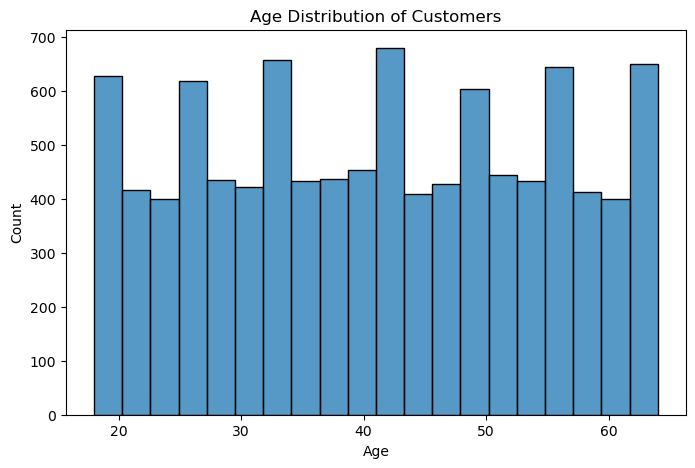

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=20)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

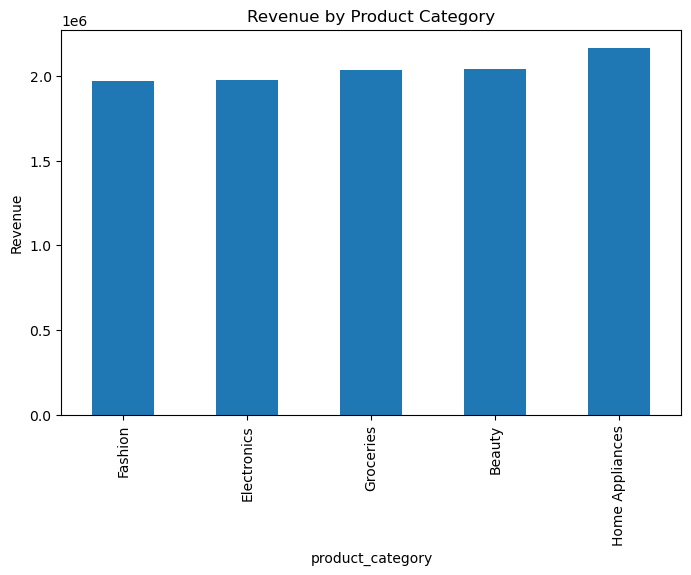

In [ ]:
plt.figure(figsize=(8,5))

df.groupby("product_category")["purchase_amount"]\
.sum()\
.sort_values()\
.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.ylabel("Revenue")

plt.show()

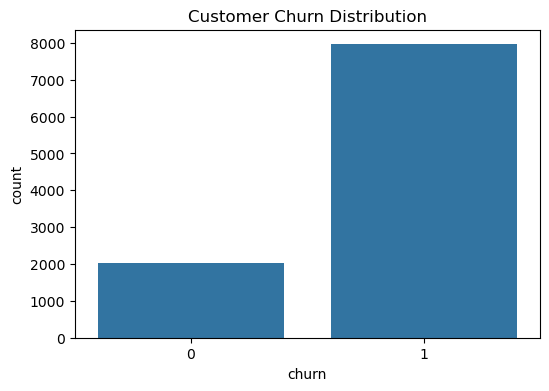

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x="churn", data=df)

plt.title("Customer Churn Distribution")

plt.show()

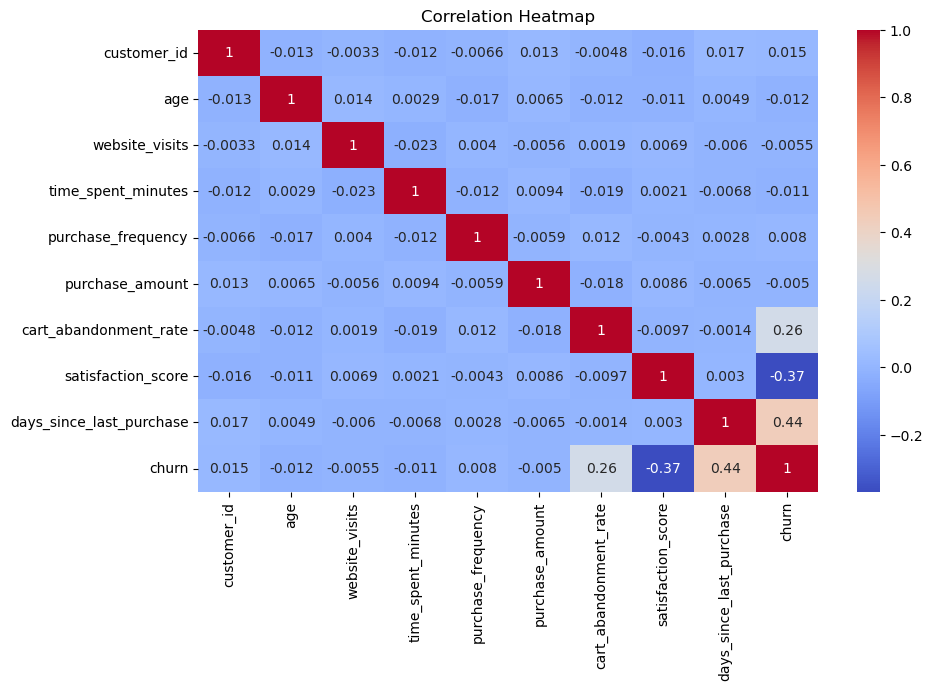

In [ ]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

## Feature Engineering

Additional features were created to improve model performance and capture customer purchasing behavior.

In [ ]:
df["average_spend_per_visit"] = (
    df["purchase_amount"] / df["website_visits"]
)

df["engagement_score"] = (
    df["website_visits"] * df["time_spent_minutes"]
)

df.head()

,customer_id,age,gender,location,product_category,website_visits,time_spent_minutes,purchase_frequency,purchase_amount,cart_abandonment_rate,satisfaction_score,days_since_last_purchase,churn,average_spend_per_visit,engagement_score
0,1,56,Male,Kumasi,Electronics,33,85,5,1374.584459,0.953609,3,37,1,41.654075,2805
1,2,46,Male,Kumasi,Groceries,29,43,18,1535.246056,0.185142,4,333,1,52.939519,1247
2,3,32,Female,Kumasi,Electronics,48,32,16,1771.662373,0.951761,1,29,1,36.909633,1536
3,4,60,Female,Kumasi,Groceries,17,7,10,1307.018886,0.429737,4,92,0,76.883464,119
4,5,25,Female,Tamale,Home Appliances,13,117,6,918.905696,0.905659,3,49,1,70.685054,1521


In [ ]:
df[["average_spend_per_visit", "engagement_score"]].head()

,average_spend_per_visit,engagement_score
0,41.654075,2805
1,52.939519,1247
2,36.909633,1536
3,76.883464,119
4,70.685054,1521


In [ ]:
le = LabelEncoder()

df["gender"] = le.fit_transform(df["gender"])
df["location"] = le.fit_transform(df["location"])
df["product_category"] = le.fit_transform(df["product_category"])

print("Categorical variables encoded successfully!")

Categorical variables encoded successfully!


In [ ]:
df.head()

,customer_id,age,gender,location,product_category,website_visits,time_spent_minutes,purchase_frequency,purchase_amount,cart_abandonment_rate,satisfaction_score,days_since_last_purchase,churn,average_spend_per_visit,engagement_score
0,1,56,1,2,1,33,85,5,1374.584459,0.953609,3,37,1,41.654075,2805
1,2,46,1,2,3,29,43,18,1535.246056,0.185142,4,333,1,52.939519,1247
2,3,32,0,2,1,48,32,16,1771.662373,0.951761,1,29,1,36.909633,1536
3,4,60,0,2,3,17,7,10,1307.018886,0.429737,4,92,0,76.883464,119
4,5,25,0,4,4,13,117,6,918.905696,0.905659,3,49,1,70.685054,1521


In [ ]:
X = df.drop("churn", axis=1)
y = df["churn"]

print(X.shape)
print(y.shape)

(10000, 14)
(10000,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (8000, 14)
Testing set: (2000, 14)


In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
predictions = model.predict(X_test)

print(predictions[:10])

[1 1 1 1 1 1 1 1 1 1]


In [ ]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [ ]:
print("Accuracy:",accuracy)

Accuracy: 1.0


In [ ]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       403
           1       1.00      1.00      1.00      1597

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



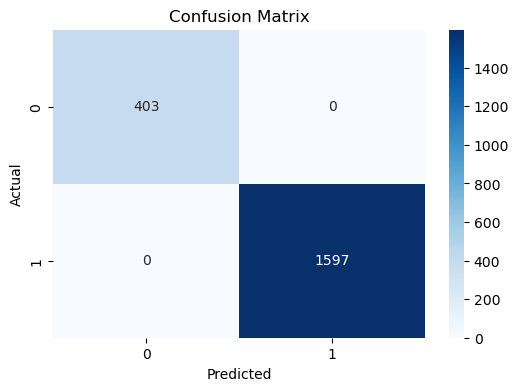

In [ ]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
11,days_since_last_purchase,0.376581
10,satisfaction_score,0.308613
9,cart_abandonment_rate,0.228026
0,customer_id,0.012551
12,average_spend_per_visit,0.011408
13,engagement_score,0.010871
8,purchase_amount,0.010766
6,time_spent_minutes,0.009284
1,age,0.008746
5,website_visits,0.007689


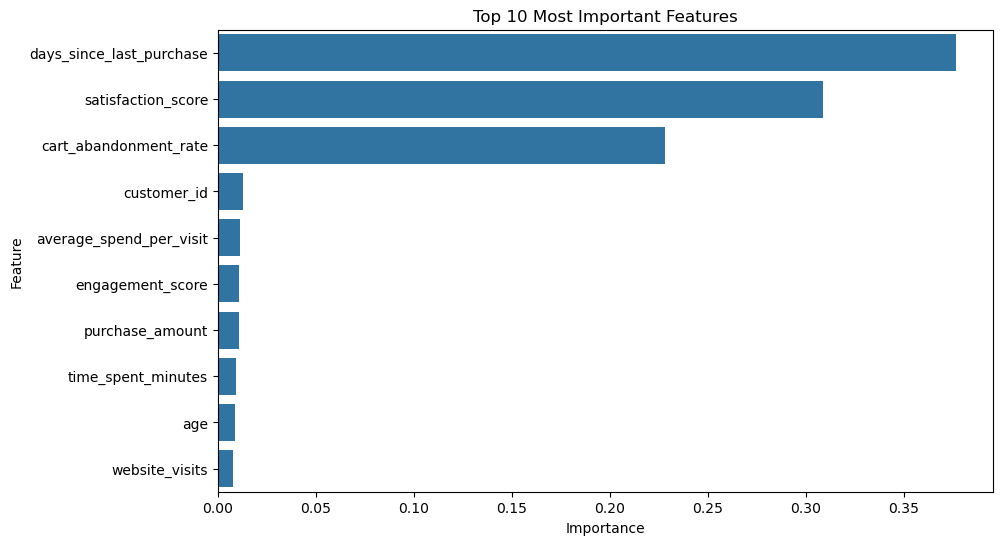

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features")

plt.show()

# Business Recommendations

## Key Findings

1. Customers with long periods of inactivity are more likely to churn.

2. Customer satisfaction is strongly associated with retention.

3. Cart abandonment behavior is an indicator of churn risk.

4. Home Appliances generated the highest revenue among product categories.

## Recommendations

- Implement customer retention campaigns targeting inactive users.

- Introduce loyalty and rewards programs.

- Improve customer satisfaction through personalized experiences.

- Reduce cart abandonment using reminder emails and promotional incentives.

- Increase investment in high-performing product categories.

# Big Data Tool Utilization

For this assessment, Python, Pandas, NumPy, and Jupyter Notebook were used for data processing and analysis.

Although the dataset is synthetic and manageable on a single machine, Pandas provides scalable data manipulation capabilities suitable for medium-sized datasets.

In a production environment with millions of records, technologies such as Apache Spark, Kafka, or Elasticsearch could be integrated to process streaming customer activity data and support real-time analytics.

The chosen tools provide efficient data cleaning, feature engineering, visualization, and predictive modeling capabilities.